In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import PlotStyler
from pynamicalsys import ContinuousDynamicalSystem as cds
from pynamicalsys import HamiltonianSystem as HS

In [2]:
time_step = 0.01

In [3]:
E = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y = -0.25
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)

dof = 2
q = np.array([x, y])
p = np.array([px, py])

u = np.array([x, y, px, py])

total_time = 10000

In [4]:
ds = cds(model="henon heiles")
ds.integrator("rk4", time_step=time_step)

In [5]:
%%time
lyapunov_spectrum = ds.lyapunov(u, total_time, return_history=True)

CPU times: user 4.29 s, sys: 65.8 ms, total: 4.36 s
Wall time: 4.37 s


In [6]:
lyapunov_spectrum.shape

(1000001, 5)

In [7]:
lyapunov_spectrum[-1, 1:], lyapunov_spectrum[-1, 1:].sum()

(array([ 0.03787512,  0.00047846, -0.00064519, -0.0377084 ]),
 np.float64(-8.988719490954367e-12))

In [8]:
hs = HS(model="henon heiles")
hs.integrator("svy4", time_step=time_step)

In [9]:
%%time
symp_lyapunov_spectrum = hs.lyapunov(q, p, total_time, return_history=True)

CPU times: user 5.39 s, sys: 32.9 ms, total: 5.43 s
Wall time: 5.44 s


In [10]:
hs.lyapunov(q, p, total_time, num_exponents=1)

np.float64(0.052181119317014406)

In [11]:
%%time
symp_maximum_lyapunov = hs.lyapunov(q, p, total_time, return_history=True, num_exponents=1)

CPU times: user 3.08 s, sys: 9.67 ms, total: 3.09 s
Wall time: 3.09 s


In [12]:
symp_lyapunov_spectrum[-1, 1:], symp_lyapunov_spectrum[-1, 1:].sum(), symp_maximum_lyapunov[-1, 1]

(array([ 0.0521435 ,  0.00065072, -0.00077281, -0.05202141]),
 np.float64(2.983724378680108e-16),
 np.float64(0.052181119317014406))

In [13]:
hs.integrator("vv2", time_step=time_step)

In [14]:
%%time
symp_lyapunov_spectrum_vvs = hs.lyapunov(q, p, total_time, return_history=True)

CPU times: user 1.78 s, sys: 12.1 ms, total: 1.79 s
Wall time: 1.8 s


In [15]:
%%time
symp_maximum_lyapunov_vvs = hs.lyapunov(q, p, total_time, return_history=True, num_exponents=1)

CPU times: user 1.42 s, sys: 8.51 ms, total: 1.43 s
Wall time: 1.43 s


In [16]:
symp_lyapunov_spectrum_vvs[-1, 1:], symp_lyapunov_spectrum_vvs[-1, 1:].sum(), symp_maximum_lyapunov_vvs[-1, 1]

(array([ 0.05969748,  0.00067774, -0.00080001, -0.05957521]),
 np.float64(-1.1796119636642288e-16),
 np.float64(0.05973515904008611))

In [17]:
hs.integrator("imp", time_step=time_step)

In [18]:
%%time
symp_lyapunov_spectrum_imp = hs.lyapunov(q, p, total_time, return_history=True)

/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research/Projects/pynamicalsys/src/pynamicalsys/hamiltonian_systems/lyapunov.py:262: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  q, p, dv = integrator_traj_tan(


CPU times: user 7.29 s, sys: 49.9 ms, total: 7.34 s
Wall time: 7.36 s


In [20]:
%%time
symp_maximum_lyapunov_imp = hs.lyapunov(q, p, total_time, return_history=True, num_exponents=1)

CPU times: user 3.9 s, sys: 17 ms, total: 3.92 s
Wall time: 3.92 s


In [21]:
symp_lyapunov_spectrum_imp[-1, 1:], symp_lyapunov_spectrum_imp[-1, 1:].sum(), symp_maximum_lyapunov_imp[-1, 1]

(array([ 0.04835765,  0.00064102, -0.00076342, -0.04823525]),
 np.float64(-1.457167719820518e-16),
 np.float64(0.04839538259166008))

<Figure size 640x480 with 0 Axes>

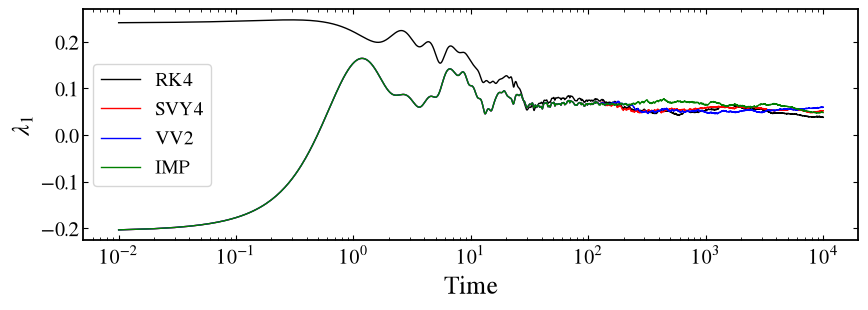

In [25]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(figsize=(10, 3))

plt.plot(lyapunov_spectrum[:, 0], lyapunov_spectrum[:, 1], "k", label="RK4")

plt.plot(symp_lyapunov_spectrum[:, 0], symp_lyapunov_spectrum[:, 1], "r", label="SVY4")

plt.plot(symp_lyapunov_spectrum_vvs[:, 0], symp_lyapunov_spectrum_vvs[:, 1], "b", label="VV2")

plt.plot(symp_lyapunov_spectrum_imp[:, 0], symp_lyapunov_spectrum_imp[:, 1], "g", label="IMP")

plt.legend(loc="best")
plt.xlabel("Time")
plt.ylabel(r"$\lambda_1$")
plt.xscale("log")
# plt.ylim(1e-2, 0.4)
# plt.yscale("log")